# 17.5 Recurrent Autoencoders

In [3]:
import matplotlib.pyplot as plt
from typing import Optional, Sequence
%matplotlib inline

def plot_images(images_norm: Sequence[Sequence[Sequence[float]]], labels: Sequence[int], label_text: str = "Label", n_cols: int = 10, sup_title: Optional[str] = None) -> None:
    n_images = len(images_norm)
    n_rows = round(np.ceil(n_images / n_cols))
    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, squeeze=False, figsize=(20, n_rows * 2 + 1), constrained_layout=True)
    for ax, img, label in zip(axs.ravel(), images_norm, labels):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(f"{label_text}: {label}", fontsize="large", fontweight="bold")
    if sup_title is not None:
        fig.suptitle(sup_title, fontsize="x-large", fontweight="bold")

##### Data

In [4]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

(x_train_valid, y_train_valid), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_valid, y_train_valid, test_size=0.2, random_state=42
)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

x_train: (48000, 28, 28)
x_valid: (12000, 28, 28)
x_test: (10000, 28, 28)


In [5]:
import numpy as np

classes = np.array(
    [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot",
    ]
)

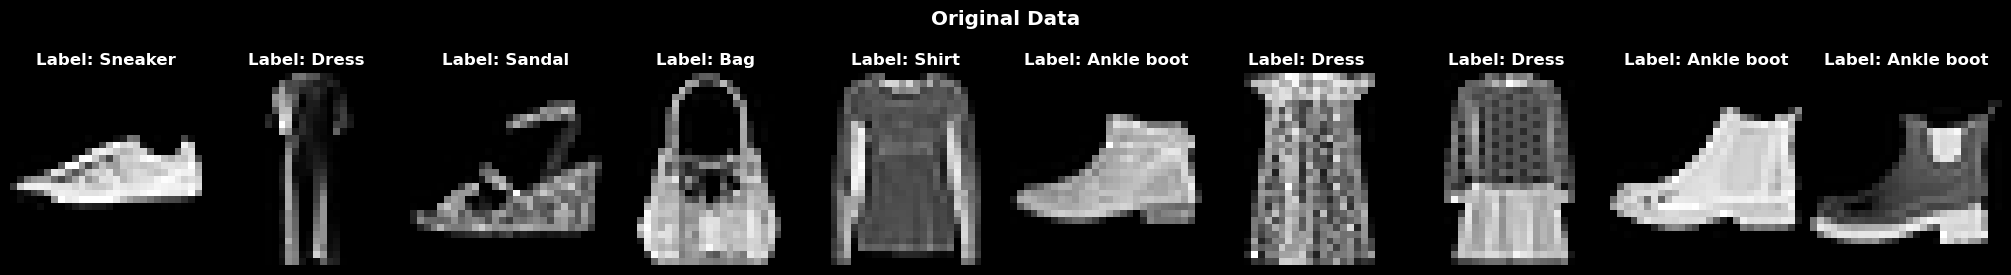

In [6]:
n_instances = 10
plot_images(
    images_norm=x_train[:n_instances],
    labels=classes[y_train[:n_instances]],
    sup_title="Original Data",
)

In [7]:
x_train_norm = x_train / 255.0
x_valid_norm = x_valid / 255.0
x_test_norm = x_test / 255.0

##### Model

In [10]:
import tensorflow as tf

recurrent_encoder = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(100, input_shape=(None, 28), return_sequences=True),
    tf.keras.layers.LSTM(30),
])

recurrent_decoder = tf.keras.models.Sequential([
    tf.keras.layers.RepeatVector(28, input_shape=(30,)),
    tf.keras.layers.LSTM(100, return_sequences=True),
    tf.keras.layers.Dense(28, activation='sigmoid')
])
recurrent_ae = tf.keras.models.Sequential([recurrent_encoder, recurrent_decoder])
recurrent_ae.compile(optimizer="adam", loss="binary_crossentropy")
recurrent_ae.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 30)                67320     
                                                                 
 sequential_7 (Sequential)   (None, 28, 28)            55228     
                                                                 
Total params: 122,548
Trainable params: 122,548
Non-trainable params: 0
_________________________________________________________________


In [11]:
cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = recurrent_ae.fit(
    x_train_norm,
    x_train_norm,
    batch_size=32,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

Epoch 1/20


2023-07-26 05:48:25.636537: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401


1500/1500 [==============================] - 16s 9ms/step - loss: 0.3623 - val_loss: 0.3218
Epoch 2/20
1500/1500 [==============================] - 12s 8ms/step - loss: 0.3128 - val_loss: 0.3058
Epoch 3/20
1500/1500 [==============================] - 13s 8ms/step - loss: 0.3029 - val_loss: 0.2981
Epoch 4/20
1500/1500 [==============================] - 14s 9ms/step - loss: 0.2953 - val_loss: 0.2926
Epoch 5/20
1500/1500 [==============================] - 13s 9ms/step - loss: 0.2901 - val_loss: 0.2887
Epoch 6/20
1500/1500 [==============================] - 14s 9ms/step - loss: 0.2864 - val_loss: 0.2845
Epoch 7/20
1500/1500 [==============================] - 14s 10ms/step - loss: 0.2836 - val_loss: 0.2821
Epoch 8/20
1500/1500 [==============================] - 19s 13ms/step - loss: 0.2817 - val_loss: 0.2803
Epoch 9/20
1500/1500 [==============================] - 17s 11ms/step - loss: 0.2799 - val_loss: 0.2799
Epoch 10/20
1500/1500 [==============================] - 15s 10ms/step - loss: 0.

##### Evaluation

313/313 [==============================] - 3s 6ms/step


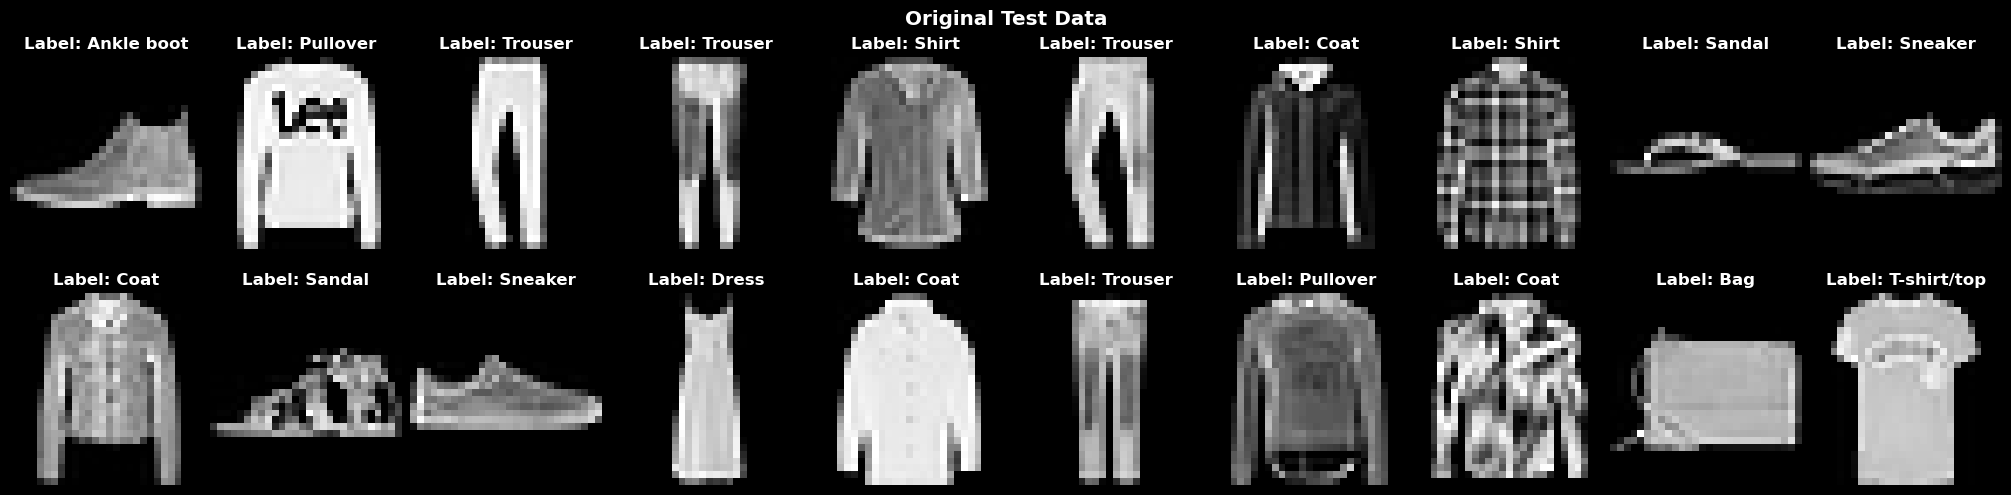

In [12]:
x_test_rec = recurrent_ae.predict(x_test_norm)

n_instances_test = 20
plot_images(
    images_norm=x_test[:n_instances_test],
    labels=classes[y_test[:n_instances_test]],
    sup_title="Original Test Data",
)

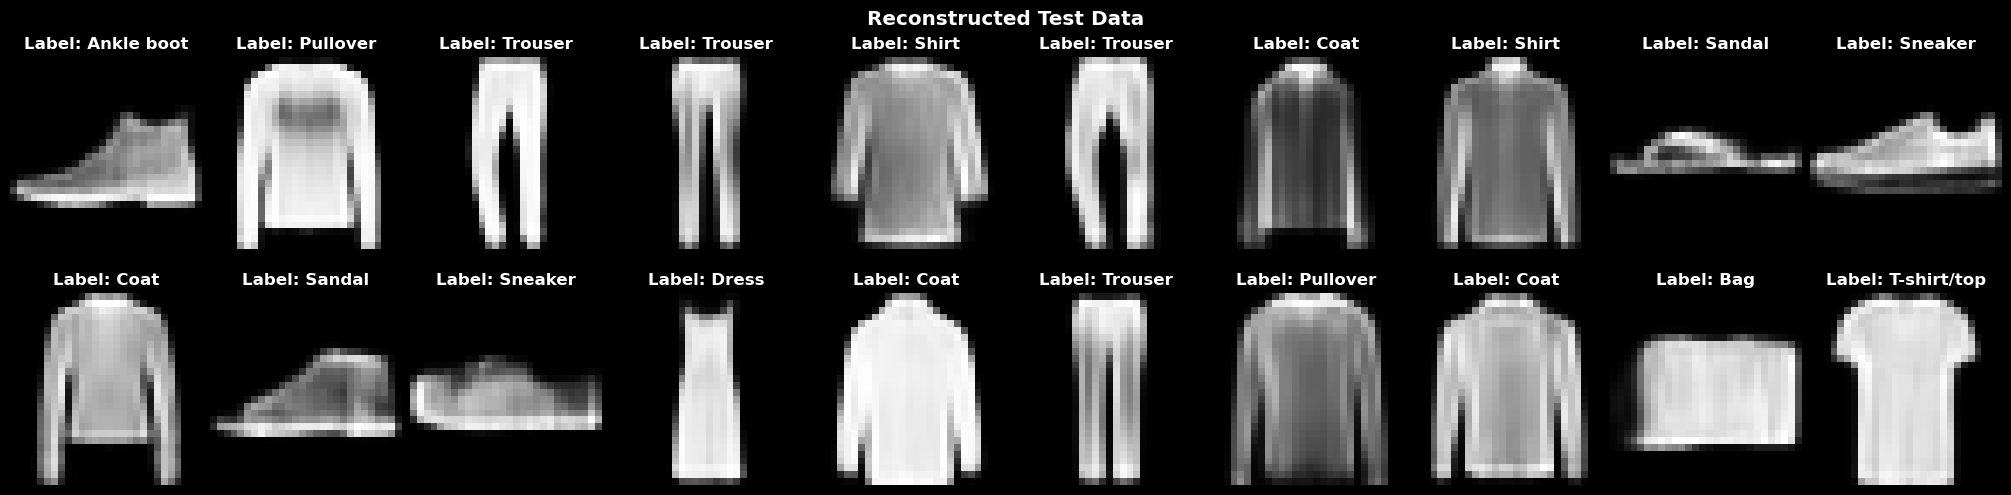

In [13]:
plot_images(
    images_norm=x_test_rec[:n_instances_test] * 255,
    labels=classes[y_test[:n_instances_test]],
    sup_title="Reconstructed Test Data",
)

##### Visualization

In [15]:
from sklearn.manifold import TSNE
from umap import UMAP

x_test_embedding = recurrent_encoder.predict(x_test_norm)

tsne = TSNE()
umap = UMAP()
x_test_2d_tsne = tsne.fit_transform(x_test_embedding)
x_test_2d_umap = umap.fit_transform(x_test_embedding)

313/313 [==============================] - 1s 2ms/step


(-73.67891387939453, 93.30849151611328, -90.40555839538574, 92.29762535095215)

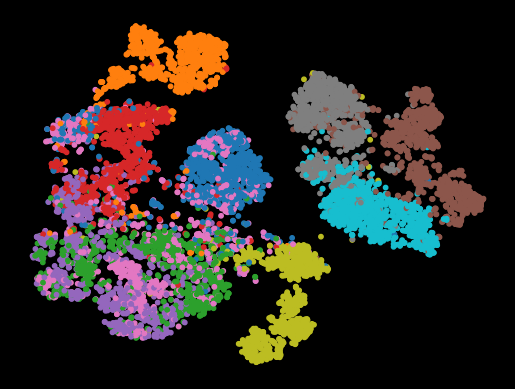

In [16]:
# t-SNE
fig, ax = plt.subplots()
ax.scatter(x_test_2d_tsne[:, 0], x_test_2d_tsne[:, 1], c=y_test, s=10, cmap="tab10")
ax.axis("off")

(-7.607917046546936, 17.12955162525177, -7.32291088104248, 12.682474708557129)

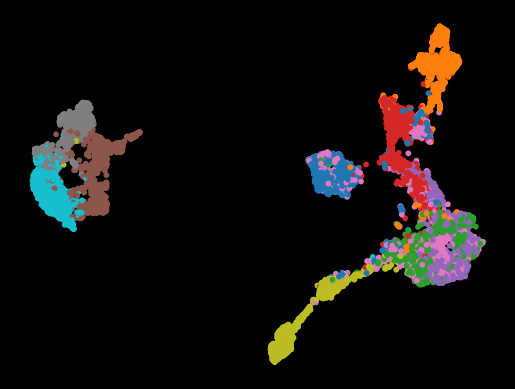

In [17]:
# UMAP
fig, ax = plt.subplots()
ax.scatter(x_test_2d_umap[:, 0], x_test_2d_umap[:, 1], c=y_test, s=10, cmap="tab10")
ax.axis("off")